# 전 세계 대기질과 호흡기 건강 지표 분석

이 노트북은 Kaggle 데이터셋 `Global Air Quality and Respiratory Health Outcomes`를 사용하여 대기오염과 호흡기 관련 병원 이용 지표의 관계를 분석합니다.

주요 분석 흐름:
1. 데이터 불러오기
2. 2020~2025년 자료 필터링
3. 월별 데이터 집계
4. 파생변수 생성: `pm25_level`, `lag_pm25_1`, `lag_pm25_2`, `rolling_pm25_3`
5. 탐색적 데이터 분석: 월별 추세 그래프, 산점도, 박스플롯, 히트맵
6. 상관분석
7. 통계적 회귀분석
8. 머신러닝 회귀 모델: 선형 회귀, 그래디언트 부스팅
9. 모델 성능 비교: MAE, RMSE, R2
10. 변수 중요도 분석
11. 분류 모델: `high_admission` 예측
12. 결론 및 한계점 정리

연구 질문:
PM2.5 농도가 높을수록 호흡기 관련 병원 이용 지표도 함께 높아지는 경향이 있는가.


In [1]:
# 1. 라이브러리 불러오기
import io
import zipfile
import warnings
warnings.filterwarnings('ignore')

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.unicode_minus'] = False

def make_ohe():
    # 구버전과 신버전 scikit-learn 모두에서 동작하도록 처리합니다.
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


In [2]:
# 2. 데이터 불러오기
# 먼저 Kaggle 데이터셋을 직접 다운로드합니다.
# 다운로드가 실패하면 air_quality_health_dataset.csv 파일을 직접 업로드합니다.

DATA_URL = 'https://www.kaggle.com/api/v1/datasets/download/tfisthis/global-air-quality-and-respiratory-health-outcomes'

try:
    response = requests.get(DATA_URL, timeout=60)
    response.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(response.content))
    print('Files in ZIP:', z.namelist())
    z.extractall('/content')
    csv_path = '/content/air_quality_health_dataset.csv'
except Exception as e:
    print('Automatic download failed:', e)
    print('Please upload air_quality_health_dataset.csv manually.')
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]

df = pd.read_csv(csv_path)
print('Original data shape:', df.shape)
df.head()


Files in ZIP: ['air_quality_health_dataset.csv']
Original data shape: (88489, 12)


,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631


In [3]:
# 3. 2020~2025년 자료 필터링 및 기본 라벨 생성

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2025-12-31')].copy()

def country_for_city(city):
    mapping = {
        'Delhi': 'India',
        'Beijing': 'China',
        'Mexico City': 'Mexico',
        'Los Angeles': 'United States',
        'London': 'United Kingdom',
        'Tokyo': 'Japan',
        'Cairo': 'Egypt',
    }
    city_text = str(city)
    if city_text.startswith('S') and 'Paulo' in city_text:
        return 'Brazil'
    return mapping.get(city, 'Unknown')

def season(month):
    if month in [3, 4, 5]:
        return 'spring'
    if month in [6, 7, 8]:
        return 'summer'
    if month in [9, 10, 11]:
        return 'fall'
    return 'winter'

def pm25_label(x):
    if pd.isna(x): return np.nan
    if x <= 15: return 'good'
    if x <= 35: return 'moderate'
    if x <= 75: return 'bad'
    return 'very_bad'

def pm10_label(x):
    if pd.isna(x): return np.nan
    if x <= 30: return 'good'
    if x <= 80: return 'moderate'
    if x <= 150: return 'bad'
    return 'very_bad'

df['country'] = df['city'].map(country_for_city)
df['year_month'] = df['date'].dt.strftime('%Y-%m')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['season'] = df['month'].map(season)

print('Analysis period:', df['date'].min().date(), '~', df['date'].max().date())
print('Countries:', sorted(df['country'].dropna().unique()))
print('Cities:', sorted(df['city'].dropna().unique()))
df.head()


Analysis period: 2020-01-01 ~ 2025-12-31
Countries: ['Brazil', 'China', 'Egypt', 'India', 'Japan', 'Mexico', 'United Kingdom', 'United States']
Cities: ['Beijing', 'Cairo', 'Delhi', 'London', 'Los Angeles', 'Mexico City', 'São Paulo', 'Tokyo']


,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity,country,year_month,year,month,season
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337,United States,2020-01,2020,1,winter
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545,China,2020-01,2020,1,winter
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539,United Kingdom,2020-01,2020,1,winter
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552,Mexico,2020-01,2020,1,winter
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631,India,2020-01,2020,1,winter


In [4]:
# 4. 월별 데이터 집계
# 한 행이 하나의 국가-도시-월 관측치를 의미합니다.

monthly = df.groupby(['country', 'city', 'year_month', 'year', 'month', 'season'], as_index=False).agg({
    'aqi': 'mean',
    'pm2_5': 'mean',
    'pm10': 'mean',
    'no2': 'mean',
    'o3': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'hospital_admissions': 'mean',
    'hospital_capacity': 'mean',
    'population_density': 'first',
    'date': 'count'
}).rename(columns={'pm2_5': 'pm25', 'date': 'n_days'})

monthly = monthly.sort_values(['country', 'city', 'year', 'month']).reset_index(drop=True)

for col in ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_admissions', 'hospital_capacity']:
    monthly[col] = monthly[col].round(3)

overall_monthly = monthly.groupby(['year_month', 'year', 'month', 'season'], as_index=False).agg({
    'aqi': 'mean',
    'pm25': 'mean',
    'pm10': 'mean',
    'no2': 'mean',
    'o3': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'hospital_admissions': 'mean',
    'hospital_capacity': 'mean',
    'n_days': 'sum'
})

for col in ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_admissions', 'hospital_capacity']:
    overall_monthly[col] = overall_monthly[col].round(3)

print('City-month dataset shape:', monthly.shape)
print('Overall monthly dataset shape:', overall_monthly.shape)
monthly.head()


City-month dataset shape: (498, 17)
Overall monthly dataset shape: (72, 14)


,country,city,year_month,year,month,season,aqi,pm25,pm10,no2,o3,temperature,humidity,hospital_admissions,hospital_capacity,population_density,n_days
0,Brazil,São Paulo,2020-06,2020,6,summer,392.0,57.60,24.4,43.5,36.4,33.5,42.0,20.0,188.0,Urban,1
1,Brazil,São Paulo,2021-01,2021,1,winter,301.0,22.50,20.2,46.9,52.5,2.5,45.0,5.0,1604.0,Rural,1
2,Brazil,São Paulo,2021-02,2021,2,winter,390.5,40.95,30.8,34.5,61.0,7.4,58.5,9.0,1204.5,Urban,2
3,Brazil,São Paulo,2021-03,2021,3,spring,97.0,23.60,45.7,23.6,32.9,3.5,36.0,6.0,712.0,Urban,1
4,Brazil,São Paulo,2021-04,2021,4,spring,26.0,27.30,84.7,13.3,16.7,2.8,59.0,1.0,469.0,Urban,1


In [5]:
# 5. 파생변수 생성
# pm25_level: PM2.5 농도 수준을 나타내는 범주형 변수
# lag_pm25_1: 전월 PM2.5
# lag_pm25_2: 2개월 전 PM2.5
# rolling_pm25_3: 최근 3개월 PM2.5 이동평균

monthly['pm25_level'] = monthly['pm25'].map(pm25_label)
monthly['pm10_level'] = monthly['pm10'].map(pm10_label)
monthly['lag_pm25_1'] = monthly.groupby(['country', 'city'])['pm25'].shift(1).round(3)
monthly['lag_pm25_2'] = monthly.groupby(['country', 'city'])['pm25'].shift(2).round(3)
monthly['rolling_pm25_3'] = (
    monthly.groupby(['country', 'city'])['pm25']
    .transform(lambda s: s.rolling(window=3, min_periods=3).mean())
    .round(3)
)
monthly['lag_hospital_admissions_1'] = monthly.groupby(['country', 'city'])['hospital_admissions'].shift(1).round(3)

print(monthly[['country', 'city', 'year_month', 'pm25', 'pm25_level', 'lag_pm25_1', 'lag_pm25_2', 'rolling_pm25_3', 'hospital_admissions']].head(12))


   country       city year_month   pm25 pm25_level  lag_pm25_1  lag_pm25_2  \
0   Brazil  São Paulo    2020-06  57.60        bad         NaN         NaN   
1   Brazil  São Paulo    2021-01  22.50   moderate       57.60         NaN   
2   Brazil  São Paulo    2021-02  40.95        bad       22.50       57.60   
3   Brazil  São Paulo    2021-03  23.60   moderate       40.95       22.50   
4   Brazil  São Paulo    2021-04  27.30   moderate       23.60       40.95   
5   Brazil  São Paulo    2021-06  32.20   moderate       27.30       23.60   
6   Brazil  São Paulo    2021-08  42.10        bad       32.20       27.30   
7   Brazil  São Paulo    2021-09  28.70   moderate       42.10       32.20   
8   Brazil  São Paulo    2021-10   8.20       good       28.70       42.10   
9   Brazil  São Paulo    2021-11   2.60       good        8.20       28.70   
10  Brazil  São Paulo    2021-12  42.90        bad        2.60        8.20   
11  Brazil  São Paulo    2022-02  52.70        bad       42.90  

## 탐색적 데이터 분석

다음 셀들은 탐색적 데이터 분석을 수행합니다. 본격적인 통계 분석과 머신러닝 모델링 전에, 데이터의 방향성이 연구 가설과 어느 정도 일치하는지 확인하기 위한 단계입니다.


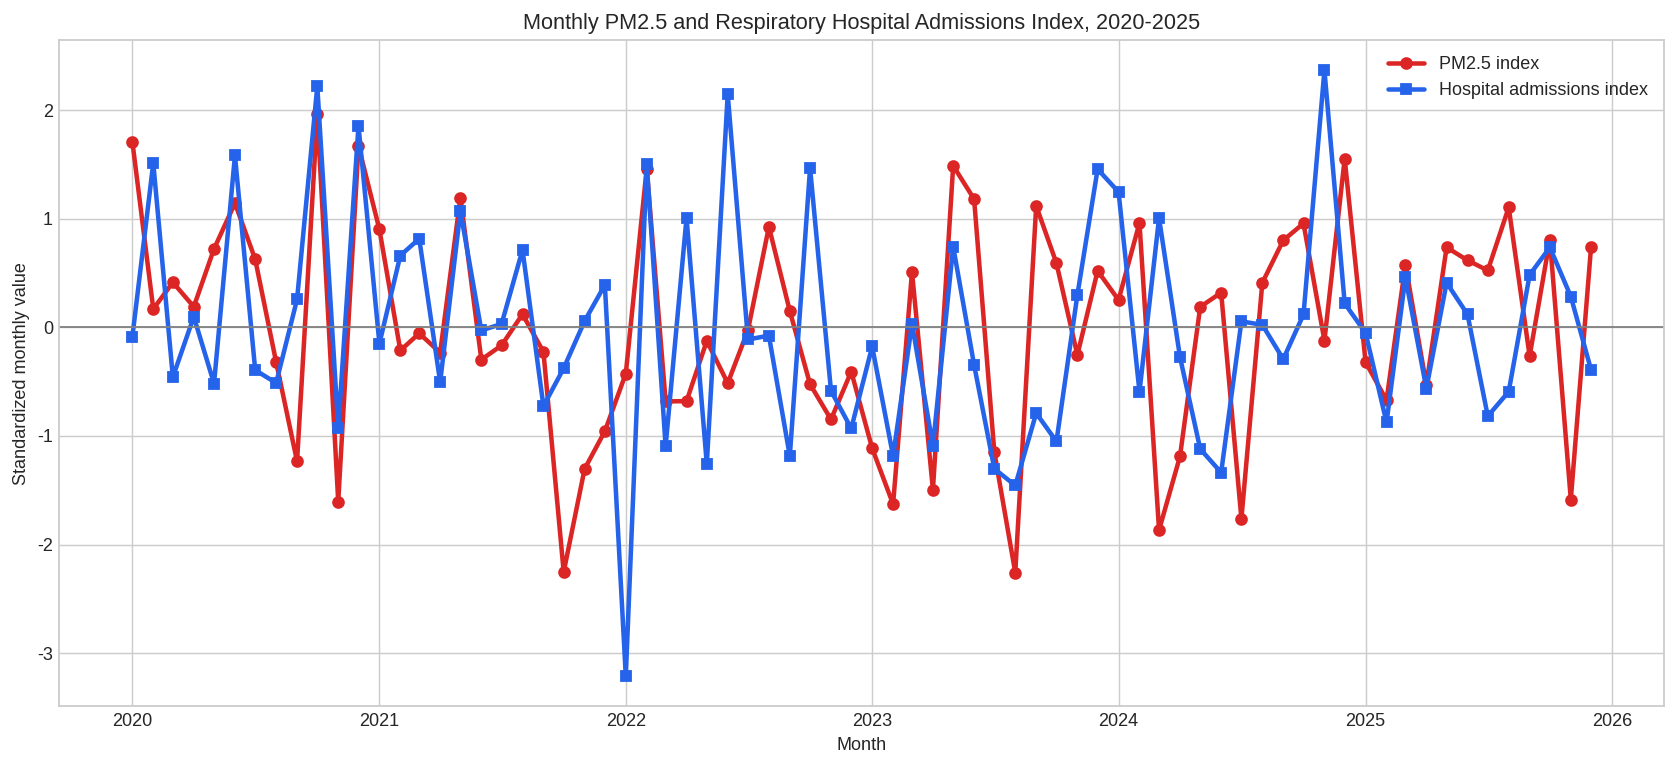

In [6]:
# 6. 탐색적 분석 1: 월별 추세 그래프
# PM2.5와 병원 이용 지표의 단위가 다르므로 표준화 값을 사용합니다.

trend = overall_monthly.copy()
trend['date'] = pd.to_datetime(trend['year_month'] + '-01')
trend['pm25_index'] = (trend['pm25'] - trend['pm25'].mean()) / trend['pm25'].std()
trend['admission_index'] = (trend['hospital_admissions'] - trend['hospital_admissions'].mean()) / trend['hospital_admissions'].std()

plt.figure(figsize=(13, 6))
plt.plot(trend['date'], trend['pm25_index'], color='#dc2626', marker='o', linewidth=2.5, label='PM2.5 index')
plt.plot(trend['date'], trend['admission_index'], color='#2563eb', marker='s', linewidth=2.5, label='Hospital admissions index')
plt.axhline(0, color='gray', linewidth=1)
plt.title('Monthly PM2.5 and Respiratory Hospital Admissions Index, 2020-2025')
plt.xlabel('Month')
plt.ylabel('Standardized monthly value')
plt.legend()
plt.tight_layout()
plt.savefig('/content/graph_1_pm25_admissions_trend.png', dpi=180, bbox_inches='tight')
plt.show()


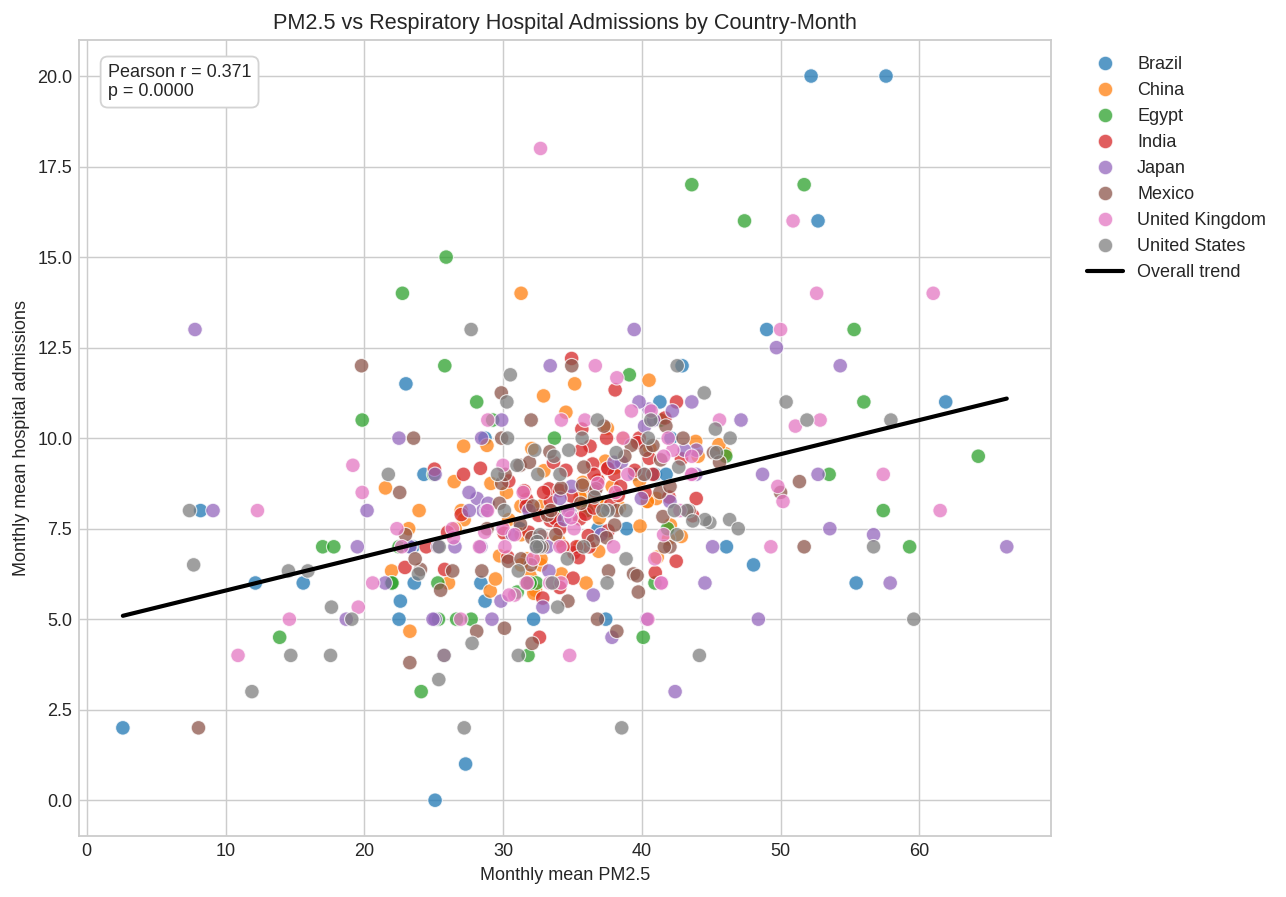

In [7]:
# 7. 탐색적 분석 2: 산점도
# 점 하나는 하나의 국가-도시-월 관측치를 의미합니다.

scatter = monthly.dropna(subset=['pm25', 'hospital_admissions']).copy()
r, p = pearsonr(scatter['pm25'], scatter['hospital_admissions'])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=scatter, x='pm25', y='hospital_admissions', hue='country', s=65, alpha=0.75)

x = np.linspace(scatter['pm25'].min(), scatter['pm25'].max(), 200)
z = np.polyfit(scatter['pm25'], scatter['hospital_admissions'], 1)
plt.plot(x, z[0] * x + z[1], color='black', linewidth=2.3, label='Overall trend')

plt.text(0.03, 0.97, f'Pearson r = {r:.3f}\np = {p:.4f}', transform=plt.gca().transAxes, va='top', ha='left', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='lightgray'))
plt.title('PM2.5 vs Respiratory Hospital Admissions by Country-Month')
plt.xlabel('Monthly mean PM2.5')
plt.ylabel('Monthly mean hospital admissions')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/graph_2_pm25_admissions_scatter.png', dpi=180, bbox_inches='tight')
plt.show()


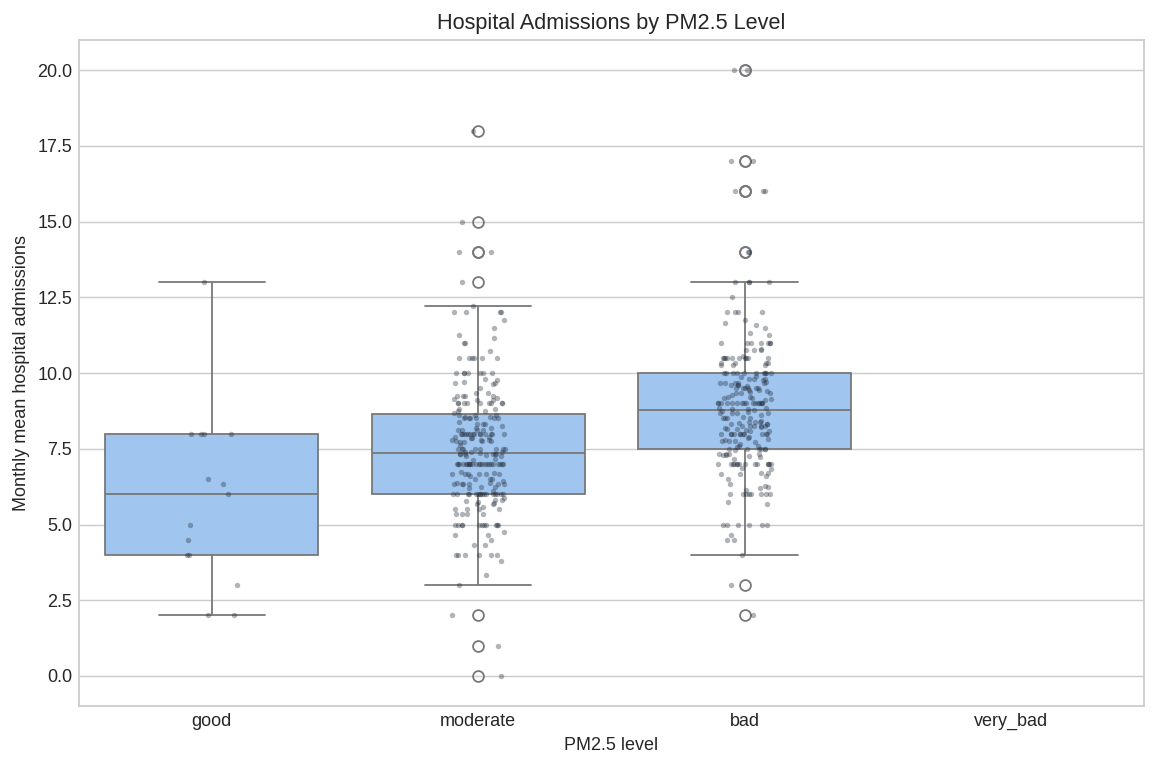

In [8]:
# 8. 탐색적 분석 3: PM2.5 수준별 박스플롯
# PM2.5 오염 수준별 병원 이용 지표의 분포를 비교합니다.

level_order = ['good', 'moderate', 'bad', 'very_bad']
plt.figure(figsize=(9, 6))
sns.boxplot(data=monthly, x='pm25_level', y='hospital_admissions', order=level_order, color='#93c5fd')
sns.stripplot(data=monthly, x='pm25_level', y='hospital_admissions', order=level_order, color='#1f2937', alpha=0.35, size=3)
plt.title('Hospital Admissions by PM2.5 Level')
plt.xlabel('PM2.5 level')
plt.ylabel('Monthly mean hospital admissions')
plt.tight_layout()
plt.savefig('/content/graph_3_boxplot_pm25_level.png', dpi=180, bbox_inches='tight')
plt.show()


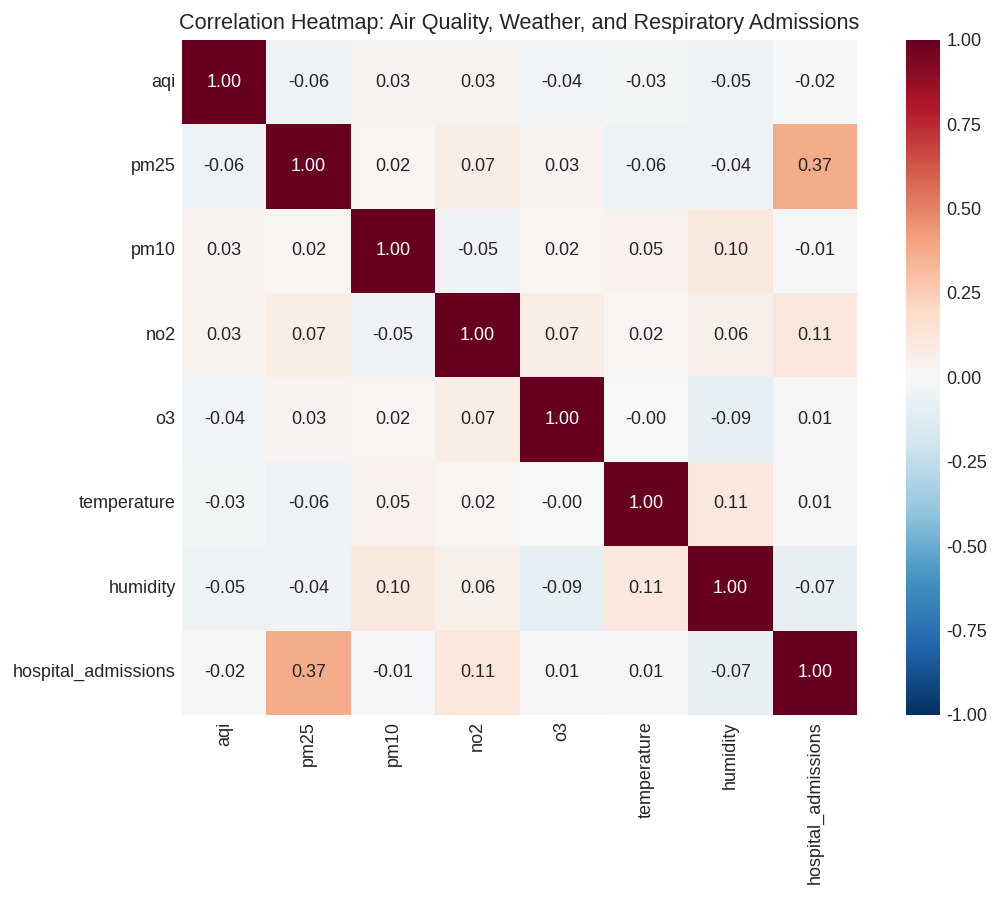

In [9]:
# 9. 탐색적 분석 4: 상관관계 히트맵

numeric_cols = ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_admissions']
plt.figure(figsize=(9, 7))
sns.heatmap(monthly[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap: Air Quality, Weather, and Respiratory Admissions')
plt.tight_layout()
plt.savefig('/content/graph_4_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()


In [10]:
# 10. 상관분석
# 각 변수와 hospital_admissions 사이의 단순한 쌍별 관계를 확인합니다.

analysis_vars = ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'lag_pm25_1', 'lag_pm25_2', 'rolling_pm25_3']
rows = []

for var in analysis_vars:
    sub = monthly[[var, 'hospital_admissions']].dropna()
    pearson_r, pearson_p = pearsonr(sub[var], sub['hospital_admissions'])
    spearman_r, spearman_p = spearmanr(sub[var], sub['hospital_admissions'])
    rows.append({
        'variable': var,
        'target': 'hospital_admissions',
        'n': len(sub),
        'pearson_r': round(pearson_r, 4),
        'pearson_p': round(pearson_p, 4),
        'spearman_r': round(spearman_r, 4),
        'spearman_p': round(spearman_p, 4),
    })

corr_result = pd.DataFrame(rows).sort_values('pearson_r', ascending=False)
corr_result


,variable,target,n,pearson_r,pearson_p,spearman_r,spearman_p
1,pm25,hospital_admissions,498,0.3706,0.0000,0.3696,0.0000
9,rolling_pm25_3,hospital_admissions,482,0.2183,0.0000,0.2120,0.0000
3,no2,hospital_admissions,498,0.1117,0.0126,0.0865,0.0536
7,lag_pm25_1,hospital_admissions,490,0.0320,0.4798,0.0115,0.7987
4,o3,hospital_admissions,498,0.0098,0.8276,0.0439,0.3286
5,temperature,hospital_admissions,498,0.0072,0.8721,-0.0190,0.6727
8,lag_pm25_2,hospital_admissions,482,-0.0044,0.9227,0.0246,0.5895
2,pm10,hospital_admissions,498,-0.0141,0.7528,-0.0107,0.8125
0,aqi,hospital_admissions,498,-0.0153,0.7329,-0.0376,0.4020
6,humidity,hospital_admissions,498,-0.0727,0.1050,-0.0547,0.2227


In [11]:
# 11. 통계적 회귀분석
# 주요 대기오염 변수, 기상 변수, 계절, 국가 차이를 통제하는 모델입니다.
# 단순 예측뿐 아니라 변수 해석에도 유용합니다.

try:
    import statsmodels.formula.api as smf
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels'])
    import statsmodels.formula.api as smf

regression_data = monthly.dropna(subset=[
    'hospital_admissions', 'pm25', 'pm10', 'no2', 'o3',
    'temperature', 'humidity', 'lag_pm25_1', 'lag_pm25_2', 'rolling_pm25_3',
    'season', 'country'
]).copy()

formula = (
    'hospital_admissions ~ pm25 + pm10 + no2 + o3 + temperature + humidity + '
    'lag_pm25_1 + lag_pm25_2 + rolling_pm25_3 + C(season) + C(country)'
)

ols_model = smf.ols(formula=formula, data=regression_data).fit()
print(ols_model.summary())


                             OLS Regression Results                            
Dep. Variable:     hospital_admissions   R-squared:                       0.150
Model:                             OLS   Adj. R-squared:                  0.115
Method:                  Least Squares   F-statistic:                     4.290
Date:                 Mon, 01 Jun 2026   Prob (F-statistic):           7.61e-09
Time:                         23:13:45   Log-Likelihood:                -1065.9
No. Observations:                  482   AIC:                             2172.
Df Residuals:                      462   BIC:                             2255.
Df Model:                           19                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

## 머신러닝 회귀 분석

다음 셀들은 대기오염 변수, 기상 변수, 시차 변수, 이동평균 변수, 월, 계절, 국가 정보를 이용하여 `hospital_admissions`를 예측하는 머신러닝 회귀 모델을 구성합니다.

Random Forest는 사용하지 않고, 다음 두 모델만 사용합니다.
- 선형 회귀
- 그래디언트 부스팅 회귀 모델


In [12]:
# 12. 모델링 데이터 준비 및 학습/평가 데이터 분리
# 시간 순서를 고려하여 2020~2023년은 학습, 2024~2025년은 평가 데이터로 사용합니다.

features_numeric = [
    'pm25', 'pm10', 'no2', 'o3', 'temperature', 'humidity',
    'lag_pm25_1', 'lag_pm25_2', 'rolling_pm25_3', 'month'
]
features_categorical = ['country', 'season']
target = 'hospital_admissions'

model_data = monthly.dropna(subset=features_numeric + features_categorical + [target]).copy()

train_df = model_data[model_data['year'] <= 2023].copy()
test_df = model_data[model_data['year'] >= 2024].copy()

X_train = train_df[features_numeric + features_categorical]
y_train = train_df[target]
X_test = test_df[features_numeric + features_categorical]
y_test = test_df[target]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train years:', sorted(train_df['year'].unique()))
print('Test years:', sorted(test_df['year'].unique()))


Train shape: (314, 12)
Test shape: (168, 12)
Train years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]
Test years: [np.int32(2024), np.int32(2025)]


In [13]:
# 13. 선형 회귀와 그래디언트 부스팅 모델 학습

preprocess_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numeric),
        ('cat', make_ohe(), features_categorical),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features_numeric),
        ('cat', make_ohe(), features_categorical),
    ]
)

models = {
    'Linear Regression': Pipeline([
        ('preprocess', preprocess_linear),
        ('model', LinearRegression())
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', GradientBoostingRegressor(
            random_state=42,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3
        ))
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, 'trained')


Linear Regression trained
Gradient Boosting trained


In [14]:
# 14. 모델 성능 비교: MAE, RMSE, R2

performance_rows = []
predictions = {}

for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    performance_rows.append({
        'model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
    })

performance = pd.DataFrame(performance_rows).sort_values('RMSE')
performance


,model,MAE,RMSE,R2
0,Linear Regression,1.7931,2.4021,-0.1256
1,Gradient Boosting,1.9298,2.5056,-0.2247


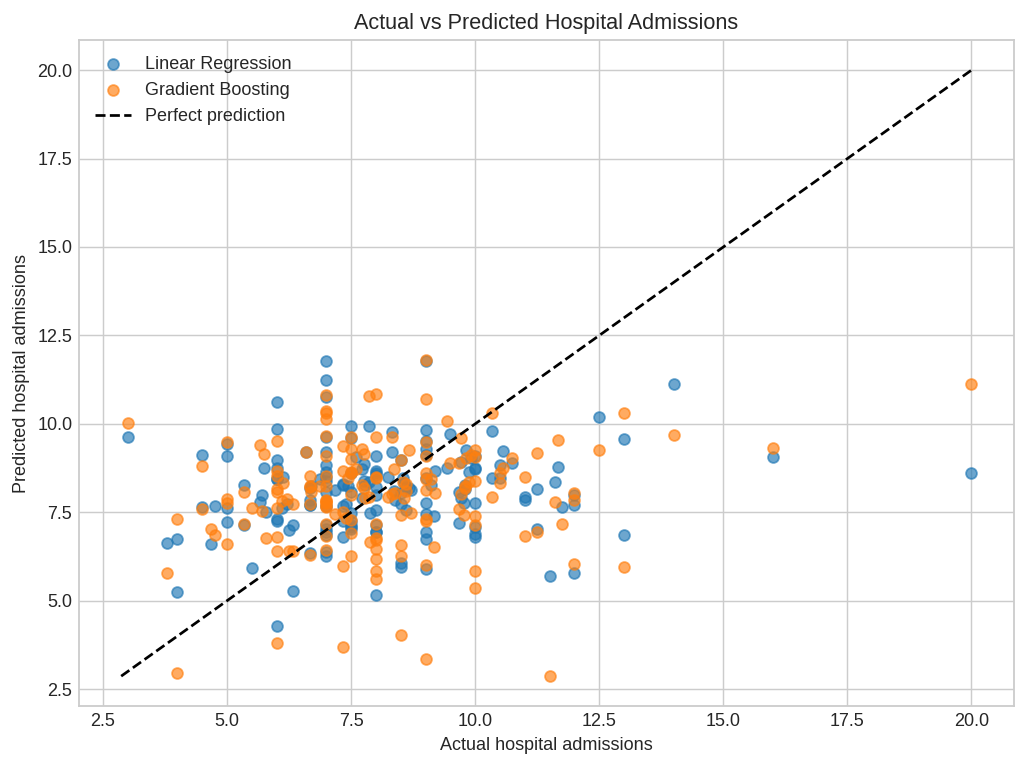

In [15]:
# 15. 실제값과 예측값 시각 비교

plt.figure(figsize=(8, 6))
for name, pred in predictions.items():
    plt.scatter(y_test, pred, alpha=0.65, label=name)

min_val = min(y_test.min(), *(pred.min() for pred in predictions.values()))
max_val = max(y_test.max(), *(pred.max() for pred in predictions.values()))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect prediction')
plt.title('Actual vs Predicted Hospital Admissions')
plt.xlabel('Actual hospital admissions')
plt.ylabel('Predicted hospital admissions')
plt.legend()
plt.tight_layout()
plt.savefig('/content/graph_5_actual_vs_predicted.png', dpi=180, bbox_inches='tight')
plt.show()


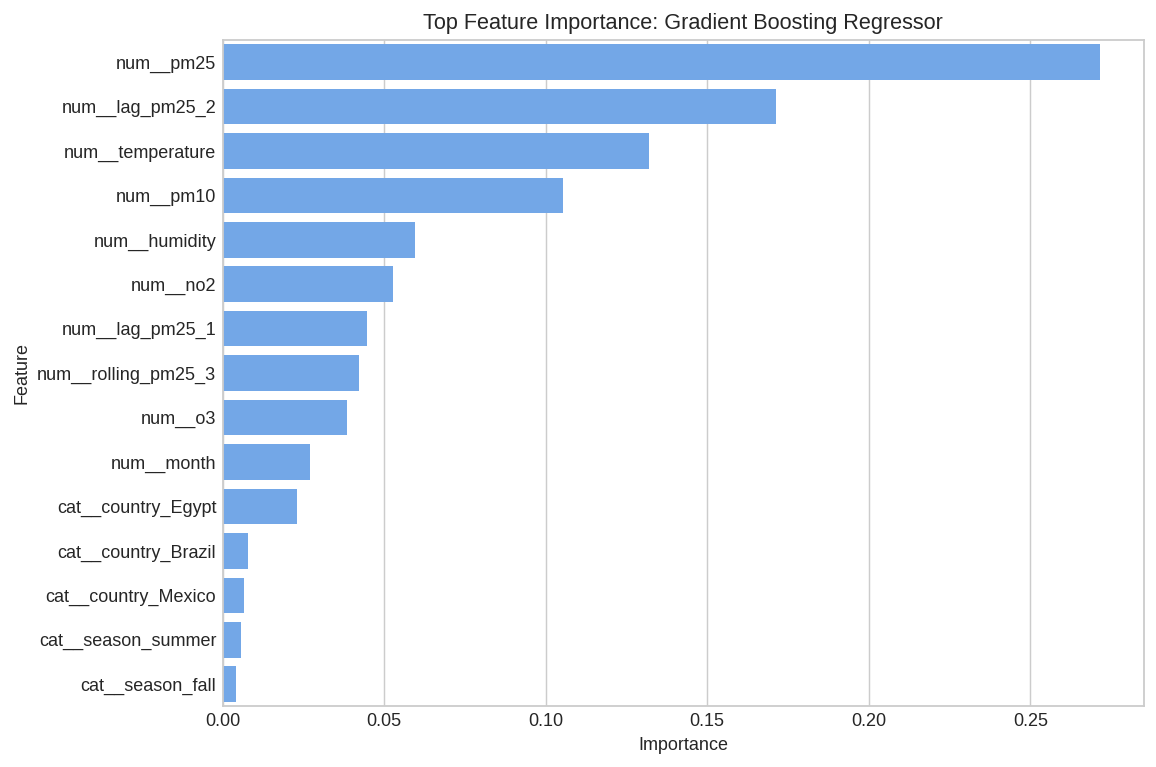

,feature,importance
0,num__pm25,0.271613
7,num__lag_pm25_2,0.171261
4,num__temperature,0.131879
1,num__pm10,0.105220
5,num__humidity,0.059417
2,num__no2,0.052600
6,num__lag_pm25_1,0.044574
8,num__rolling_pm25_3,0.042138
3,num__o3,0.038592
9,num__month,0.027155


In [16]:
# 16. 그래디언트 부스팅 기반 변수 중요도
# 어떤 변수가 예측에 크게 기여하는지 확인합니다.

gb_model = models['Gradient Boosting']
preprocessor = gb_model.named_steps['preprocess']
regressor = gb_model.named_steps['model']

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = features_numeric + list(preprocessor.named_transformers_['cat'].get_feature_names_out(features_categorical))

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': regressor.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#60a5fa')
plt.title('Top Feature Importance: Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('/content/graph_6_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()

importance_df.head(20)


## 분류 모델

추가적인 머신러닝 분석을 위해 `hospital_admissions`를 이진 라벨로 변환합니다.

- `high_admission = 1`: 병원 이용 지표가 학습 데이터의 중앙값 이상인 경우
- `high_admission = 0`: 병원 이용 지표가 학습 데이터의 중앙값보다 낮은 경우

즉, 이 단계에서는 대기오염 및 기상 변수를 이용해 병원 이용 지표가 높은 달을 예측할 수 있는지 확인합니다.


In [17]:
# 17. high_admission 라벨 생성 및 분류 모델 학습

threshold = train_df[target].median()
y_train_cls = (y_train >= threshold).astype(int)
y_test_cls = (y_test >= threshold).astype(int)

classifiers = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocess_linear),
        ('model', LogisticRegression(max_iter=2000))
    ]),
    'Gradient Boosting Classifier': Pipeline([
        ('preprocess', preprocess_tree),
        ('model', GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=3))
    ]),
}

classification_rows = []
classification_predictions = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train_cls)
    pred_cls = clf.predict(X_test)
    classification_predictions[name] = pred_cls
    classification_rows.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test_cls, pred_cls), 4),
        'f1_score': round(f1_score(y_test_cls, pred_cls), 4),
    })

classification_performance = pd.DataFrame(classification_rows).sort_values('f1_score', ascending=False)
classification_performance


,model,accuracy,f1_score
1,Gradient Boosting Classifier,0.5833,0.6237
0,Logistic Regression,0.5536,0.5989


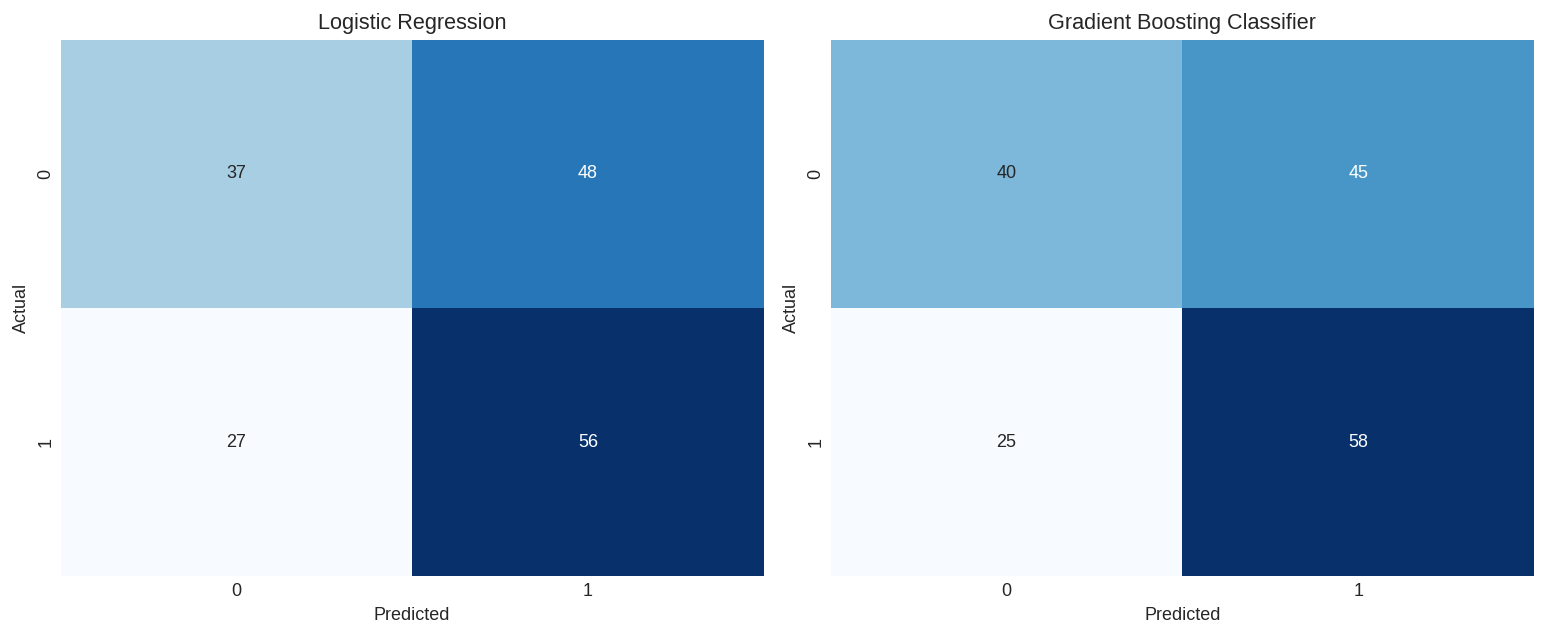


Logistic Regression
                precision    recall  f1-score   support

 low_admission       0.58      0.44      0.50        85
high_admission       0.54      0.67      0.60        83

      accuracy                           0.55       168
     macro avg       0.56      0.55      0.55       168
  weighted avg       0.56      0.55      0.55       168


Gradient Boosting Classifier
                precision    recall  f1-score   support

 low_admission       0.62      0.47      0.53        85
high_admission       0.56      0.70      0.62        83

      accuracy                           0.58       168
     macro avg       0.59      0.58      0.58       168
  weighted avg       0.59      0.58      0.58       168



In [18]:
# 18. 혼동행렬과 분류 리포트

fig, axes = plt.subplots(1, len(classifiers), figsize=(12, 5))
if len(classifiers) == 1:
    axes = [axes]

for ax, (name, pred_cls) in zip(axes, classification_predictions.items()):
    cm = confusion_matrix(y_test_cls, pred_cls)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/graph_7_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

for name, pred_cls in classification_predictions.items():
    print('\n' + '='*80)
    print(name)
    print(classification_report(y_test_cls, pred_cls, target_names=['low_admission', 'high_admission']))


In [19]:
# 19. 전처리 데이터, 그래프, 모델 결과 저장

monthly.to_csv('/content/kaggle_global_air_health_monthly_city_country_2020_2025.csv', index=False, encoding='utf-8-sig')
overall_monthly.to_csv('/content/kaggle_global_air_health_monthly_overall_2020_2025.csv', index=False, encoding='utf-8-sig')
corr_result.to_csv('/content/kaggle_global_air_health_correlation_summary_2020_2025.csv', index=False, encoding='utf-8-sig')
performance.to_csv('/content/kaggle_global_air_health_regression_model_performance.csv', index=False, encoding='utf-8-sig')
importance_df.to_csv('/content/kaggle_global_air_health_feature_importance.csv', index=False, encoding='utf-8-sig')
classification_performance.to_csv('/content/kaggle_global_air_health_classification_performance.csv', index=False, encoding='utf-8-sig')

with pd.ExcelWriter('/content/kaggle_global_air_health_final_outputs.xlsx', engine='openpyxl') as writer:
    monthly.to_excel(writer, sheet_name='monthly_city_country', index=False)
    overall_monthly.to_excel(writer, sheet_name='monthly_overall', index=False)
    corr_result.to_excel(writer, sheet_name='correlation_summary', index=False)
    performance.to_excel(writer, sheet_name='regression_performance', index=False)
    importance_df.to_excel(writer, sheet_name='feature_importance', index=False)
    classification_performance.to_excel(writer, sheet_name='classification_performance', index=False)

print('Saved files in /content')
print('/content/kaggle_global_air_health_final_outputs.xlsx')
print('/content/graph_1_pm25_admissions_trend.png')
print('/content/graph_2_pm25_admissions_scatter.png')
print('/content/graph_3_boxplot_pm25_level.png')
print('/content/graph_4_correlation_heatmap.png')
print('/content/graph_5_actual_vs_predicted.png')
print('/content/graph_6_feature_importance.png')
print('/content/graph_7_confusion_matrix.png')


Saved files in /content
/content/kaggle_global_air_health_final_outputs.xlsx
/content/graph_1_pm25_admissions_trend.png
/content/graph_2_pm25_admissions_scatter.png
/content/graph_3_boxplot_pm25_level.png
/content/graph_4_correlation_heatmap.png
/content/graph_5_actual_vs_predicted.png
/content/graph_6_feature_importance.png
/content/graph_7_confusion_matrix.png


## 결론 및 한계점

### 결론

이 노트북은 2020~2025년 국가-도시-월 단위 데이터를 사용하여 PM2.5와 호흡기 관련 병원 이용 지표의 관계를 분석합니다. 분석에는 탐색적 데이터 분석, 상관분석, 통계적 회귀분석, 머신러닝 회귀분석, 변수 중요도 분석, 이진 분류 분석이 포함됩니다.

산점도와 상관분석은 PM2.5와 호흡기 병원 이용 지표 사이의 관계 방향을 확인하는 데 사용됩니다. 회귀분석과 머신러닝 모델은 대기오염 및 기상 변수가 병원 이용 지표를 설명하거나 예측하는 데 도움이 되는지 확인하기 위해 사용됩니다.

### 연구 주제와의 연결


원래 연구 주제는 미세먼지와 감기 발병률의 관계였으나 이 데이터셋은 감기 발병률을 직접 측정하지 않는 대신 호흡기 질환 관련 방문자 수를 더 넓은 의미의 호흡기 건강 지표로 사용하며, 이로 얻을 수 있는 결과는 다음과 같다.

이 데이터셋에서는 PM2.5가 높을수록 호흡기 관련 병원 이용 지표도 높아지는 경향이 관찰된다.

### 한계점

1. `hospital_admissions`는 감기 발병률과 연관은 있을지언정 같은 지표는 아니다.
2. 국가별 의료체계, 인구구조, 보고 기준 차이가 병원 이용 지표에 영향을 줄 수 있다.
3. 월별 집계는 단기 노출 효과를 일부 가릴 수 있습니다.



In [20]:
# 20. 선택 사항: 주요 결과 파일 다운로드
# Colab에서 생성된 결과 파일을 내려받고 싶을 때 실행합니다.

from google.colab import files

for file_name in [
    '/content/kaggle_global_air_health_final_outputs.xlsx',
    '/content/graph_1_pm25_admissions_trend.png',
    '/content/graph_2_pm25_admissions_scatter.png',
    '/content/graph_3_boxplot_pm25_level.png',
    '/content/graph_4_correlation_heatmap.png',
    '/content/graph_5_actual_vs_predicted.png',
    '/content/graph_6_feature_importance.png',
    '/content/graph_7_confusion_matrix.png',
]:
    files.download(file_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>